<a href="https://colab.research.google.com/github/davidlealo/practicos_sisrec_2026/blob/main/practico04/04_content_based_imagenes_respuestaDLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctico Content-based (Imágenes)

IIC-3633, PUC Chile

**Profesor:** Denis Parra

**Alumno:** `David Leal`

En esta actividad trabajaremos con un recomendador de ropa basado netamente en las imagenes más similares extrayendo features con redes neuronales convolucionales.



In [ ]:
from keras.applications import vgg16, vgg19, ResNet50
from tensorflow.keras.utils import load_img,img_to_array
from keras.models import Model
from keras.applications.imagenet_utils import preprocess_input

from PIL import Image
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

En esta sección se trabajará con modelos pre-entrenados de redes convolucionales (CNN) que extraen caracteristicas visuales de las imagenes.

![Ejemplo de red convolucional](https://www.researchgate.net/publication/326658868/figure/fig3/AS:962202072805390@1606418259908/AlexNet-architecture-This-shows-the-process-to-obtain-the-latent-feature-vector-we-use.png)


Para los curiosos se recomienda revisar los siguientes links:

- Artículo: [Understand Deep Residual Networks](https://medium.com/@14prakash/understanding-and-implementing-architectures-of-resnet-and-resnext-for-state-of-the-art-image-cf51669e1624)
- [Keras applications](https://keras.io/applications/)

# Descarga de imagenes

In [ ]:
%%capture
!gdown 1iLOeNZw69iyYXa7QS5ZutN7ACUpkbL3x
!unzip images_fashion.zip
!mkdir images
!mv *.png images/

# Cargamos la CNN pre-entrenada en ImageNet


In [ ]:
# cargamos el modelo escoger

modelo_escogido = 'vgg19' #@param["vgg16", "vgg19"]

if modelo_escogido == 'vgg16':
  # cargar modelo
  vgg_model = vgg16.VGG16(weights='imagenet')
  # quitar la capa de clasificacion
  feat_extractor = Model(inputs=vgg_model.input, outputs=vgg_model.get_layer("fc2").output)
  # vemos resumen de la arquitectura del modelo
  feat_extractor.summary()

elif modelo_escogido == 'vgg19':
  # cargar modelo
  vgg19_model = vgg19.VGG19(weights='imagenet')
  # quitar la capa de clasificacion
  feat_extractor = Model(inputs=vgg19_model.input, outputs=vgg19_model.get_layer("fc2").output)
  # vemos resumen de la arquitectura del modelo
  feat_extractor.summary()



574710816/574710816 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,31

 Total params: 139,570,240 (532.42 MB)

 Trainable params: 139,570,240 (532.42 MB)

 Non-trainable params: 0 (0.00 B)

## Procesamiento de imágenes para dárselas como input a la CNN

In [ ]:
ls

images/  images_fashion.zip  __MACOSX/  sample_data/  style.csv  style.txt


In [ ]:
imgs_path = "images/" # ruta

imgs_model_width, imgs_model_height = 224, 224 # tamaño de las imagenes 224x224 pixeles

nb_closest_images = 5 # cantidad de imagenes similares a recomendar

In [ ]:
files = [imgs_path + x for x in os.listdir(imgs_path) if "png" in x]
print("total de imagenes:",len(files))

total de imagenes: 2184


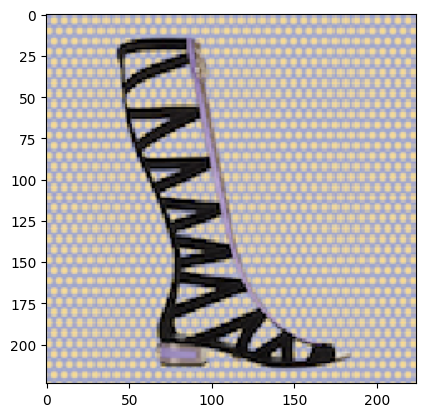

image cargada exitosamente!


In [ ]:
# vemos imagen aleatoria
import random

idx =  random.randint(0, len(files))
original = load_img(files[idx], target_size=(imgs_model_width, imgs_model_height))
plt.imshow(original)
plt.show()
print("image cargada exitosamente!")

In [ ]:
# convertir PIL image a numpy array
numpy_image = img_to_array(original)

# convertir imagen a batch de imagenes para entrenamiento más eficiente
image_batch = np.expand_dims(numpy_image, axis=0)
print('image batch size', image_batch.shape)

# preparamos la imagen para la VGG16
processed_image = preprocess_input(image_batch.copy())

processed_image

image batch size (1, 224, 224, 3)


array([[[[ 89.061,  64.221,  61.32 ],
         [ 86.061,  78.221,  76.32 ],
         [ 86.061,  78.221,  76.32 ],
         ...,
         [ 85.061,  73.221,  73.32 ],
         [ 85.061,  73.221,  73.32 ],
         [ 84.061,  72.221,  68.32 ]],

        [[ 98.061,  52.221,  42.32 ],
         [105.061,  43.221,  30.32 ],
         [105.061,  43.221,  30.32 ],
         ...,
         [103.061,  47.221,  34.32 ],
         [103.061,  47.221,  34.32 ],
         [103.061,  48.221,  36.32 ]],

        [[ 98.061,  52.221,  42.32 ],
         [105.061,  43.221,  30.32 ],
         [105.061,  43.221,  30.32 ],
         ...,
         [103.061,  47.221,  34.32 ],
         [103.061,  47.221,  34.32 ],
         [103.061,  48.221,  36.32 ]],

        ...,

        [[100.061,  49.221,  37.32 ],
         [100.061,  49.221,  35.32 ],
         [100.061,  49.221,  35.32 ],
         ...,
         [100.061,  49.221,  34.32 ],
         [100.061,  49.221,  34.32 ],
         [103.061,  48.221,  37.32 ]],

        [[

In [ ]:
# obtenemos los features (embeddings) de las imagenes pasandolas por la VGG16
img_features = feat_extractor.predict(processed_image)

print("features successfully extracted!")
print("number of image features:",img_features.size)
img_features

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
features successfully extracted!
number of image features: 4096


array([[0.       , 6.557408 , 0.       , ..., 0.       , 1.4108431,
        0.       ]], dtype=float32)

In [ ]:
img_features.shape

(1, 4096)

In [ ]:
# repetimos el mismo proceso para todas las imagenes y guardamos los batch en una lista para entregarselos procesados a la VGG16
importedImages = []

for f in files:
    filename = f
    original = load_img(filename, target_size=(224, 224))
    numpy_image = img_to_array(original)
    image_batch = np.expand_dims(numpy_image, axis=0)

    importedImages.append(image_batch)

images = np.vstack(importedImages)

processed_imgs = preprocess_input(images.copy())

In [ ]:
# obtenemos los features para cada imagen con la CNN
imgs_features = feat_extractor.predict(processed_imgs)

print("features extraidos exitosamente!")
imgs_features.shape

69/69 ━━━━━━━━━━━━━━━━━━━━ 30s 259ms/step
features extraidos exitosamente!


(2184, 4096)

In [ ]:
# computa similaridad coseno entre los features de las imagenes
cosSimilarities = cosine_similarity(imgs_features)

# guardamos los resultados en un dataframe
cos_similarities_df = pd.DataFrame(cosSimilarities, columns=files, index=files)
cos_similarities_df #.head()

,images/5_6_009.png,images/3_5_013.png,images/4_0_033.png,images/4_5_026.png,images/0_0_036.png,images/2_0_045.png,images/6_1_035.png,images/4_8_001.png,images/2_1_003.png,images/5_2_002.png,...,images/0_1_021.png,images/3_0_060.png,images/5_0_046.png,images/3_0_049.png,images/4_0_037.png,images/5_4_014.png,images/6_2_007.png,images/3_4_022.png,images/3_0_038.png,images/4_4_017.png
images/5_6_009.png,1.000000,0.336335,0.430835,0.264831,0.562668,0.369113,0.278964,0.266365,0.159930,0.362835,...,0.156964,0.422603,0.495048,0.489330,0.387135,0.299377,0.280017,0.320810,0.386289,0.396431
images/3_5_013.png,0.336335,1.000000,0.249066,0.478994,0.317311,0.212737,0.278805,0.160427,0.274907,0.322716,...,0.228939,0.319676,0.304930,0.324939,0.294779,0.247656,0.309427,0.340886,0.230499,0.309083
images/4_0_033.png,0.430835,0.249066,1.000000,0.226239,0.586264,0.603519,0.306026,0.491937,0.170287,0.224092,...,0.386737,0.562933,0.418621,0.462710,0.713991,0.226011,0.266487,0.312140,0.534573,0.425165
images/4_5_026.png,0.264831,0.478994,0.226239,1.000000,0.286531,0.185473,0.332545,0.174069,0.298482,0.287660,...,0.314343,0.238636,0.220590,0.312363,0.253169,0.266231,0.290845,0.290646,0.233147,0.331136
images/0_0_036.png,0.562668,0.317311,0.586264,0.286531,1.000000,0.458878,0.355462,0.433813,0.234965,0.263464,...,0.318183,0.529285,0.527116,0.536349,0.513102,0.273671,0.250527,0.326215,0.559433,0.404518
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
images/5_4_014.png,0.299377,0.247656,0.226011,0.266231,0.273671,0.184733,0.230396,0.214334,0.176303,0.597266,...,0.182541,0.227220,0.230785,0.306839,0.217827,1.000000,0.454902,0.566317,0.259524,0.489974
images/6_2_007.png,0.280017,0.309427,0.266487,0.290845,0.250527,0.253782,0.230446,0.231667,0.231110,0.641919,...,0.255861,0.300103,0.269468,0.319873,0.338187,0.454902,1.000000,0.546628,0.315175,0.449410
images/3_4_022.png,0.320810,0.340886,0.312140,0.290646,0.326215,0.256129,0.268415,0.276911,0.224646,0.500467,...,0.286001,0.323674,0.259033,0.347928,0.338058,0.566317,0.546628,1.000000,0.324207,0.504275
images/3_0_038.png,0.386289,0.230499,0.534573,0.233147,0.559433,0.305049,0.230407,0.550591,0.252425,0.315430,...,0.245732,0.566175,0.464868,0.445508,0.497907,0.259524,0.315175,0.324207,1.000000,0.341999


In [ ]:
# esta funcion recupera las imagenes más similares dada una imagen entregada por el usuario
def retrieve_most_similar_products(given_img):

    print("-----------------------------------------------------------------------")
    print("producto escogido:")

    original = load_img(given_img, target_size=(imgs_model_width, imgs_model_height))
    plt.imshow(original)
    plt.show()

    print("-----------------------------------------------------------------------")
    print("productos más similares:")

    closest_imgs = cos_similarities_df[given_img].sort_values(ascending=False)[1:nb_closest_images+1].index
    closest_imgs_scores = cos_similarities_df[given_img].sort_values(ascending=False)[1:nb_closest_images+1]

    for i in range(0,len(closest_imgs)):
        original = load_img(closest_imgs[i], target_size=(imgs_model_width, imgs_model_height))
        plt.imshow(original)
        plt.show()
        print("score de similaridad : ",closest_imgs_scores[i])

1100
images/1_2_042.png
-----------------------------------------------------------------------
producto escogido:


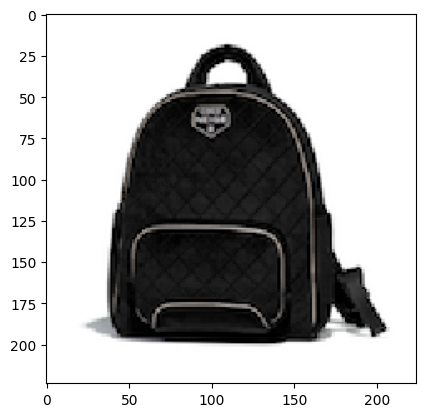

-----------------------------------------------------------------------
productos más similares:


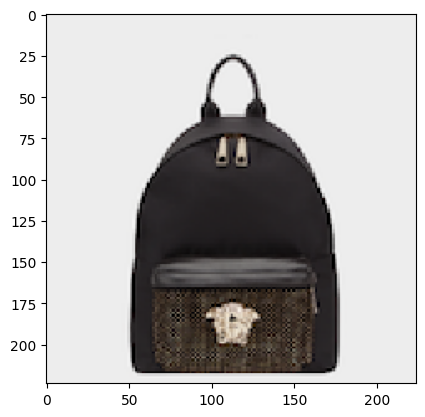

score de similaridad :  0.7788779


/tmp/ipykernel_2852/1698311365.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("score de similaridad : ",closest_imgs_scores[i])


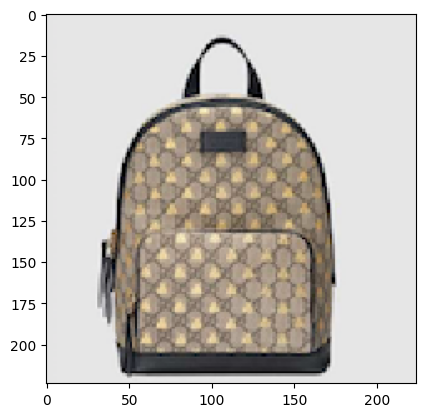

score de similaridad :  0.7460401


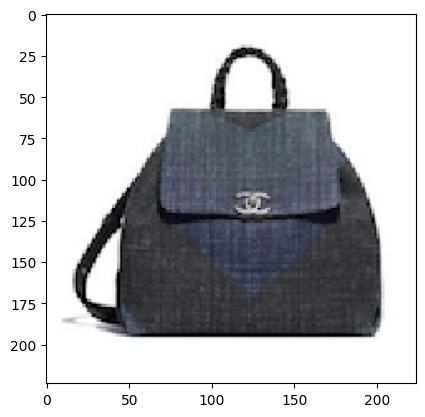

score de similaridad :  0.6591913


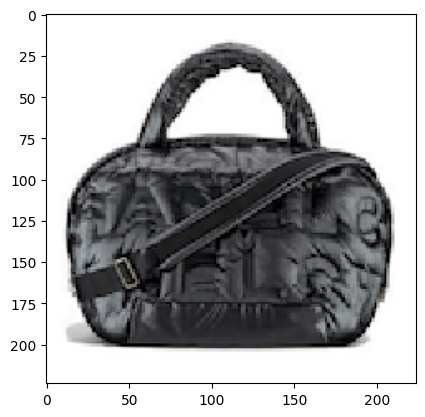

score de similaridad :  0.6550507


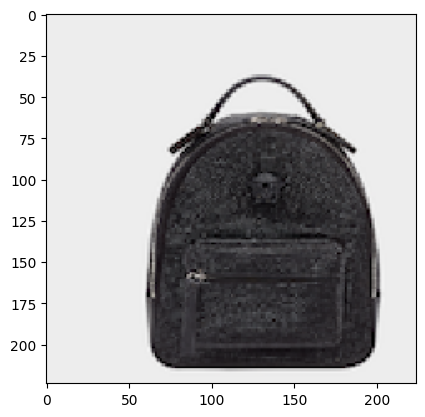

score de similaridad :  0.6316994


In [ ]:
idx = 1100 # random.randint(0, len(files))
print(idx)
print(files[idx])
retrieve_most_similar_products(files[idx])

# ACTIVIDAD

1. Mostrar 2 ejemplos de búsqueda de imagenes similares utilizando ambas arquitecturas (VGG16 y VGG19) e imprimir los resultados. (3 ptos)

2. ¿Cuál de las dos arquitecturas (VGG16 o VGG19) tiene más parámetros entrenables después de quitar la última capa de clasificación?. Justifique indicando la cantidad de parámetros de cada una. (2 ptos)


Pregunta 1:

VGG 16

In [ ]:
# busqueda 1

In [ ]:
# busqueda 2

VGG 19

In [ ]:
# busqueda 1

In [ ]:
# busqueda 2

Pregunta 2
- parámetros entrenables VGG16 sin última capa
- parámetros entrenables VGG19 sin última capa


